$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE (DS-UA 201)}\\[4pt]
\textbf{Lab: Probability Review 3 \; \& \; All-Causes Model \; \& \; Statistics Review 1}\\[6pt]
\textit{Conditional variance} \cdot \textit{Independence} \cdot \textit{Normal} \cdot \textit{ATE / ATT / ATU} \cdot \textit{Estimators, WLLN, CLT}
\end{array}
$$

---


- Compute a **conditional variance** two ways, *prove* the two forms are equal, and explain why it is a function of $X$.
- State what **independence** means, *prove* that it forces zero covariance, and explain why "uncorrelated" is weaker than "independent".
- Recognize the **Normal distribution**, the 68–95–99.7 rule, and how *standardizing* turns any Normal into the standard Normal.
- Write down the **ATE, ATT, and ATU**, break each apart with linearity of expectation, and see *in code* why a naive treated-vs-untreated comparison is biased — and how $S \perp U$ fixes it.
- Treat an **estimator** as a random variable: compute its **bias** and **variance**, and watch **consistency (WLLN)** and the **Central Limit Theorem** appear in simulation.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.stats as stats

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(201)          # 201 = the course number, so every run is reproducible

# Part 1 — Probability

## 1.1 Conditional variance

Just as the conditional expectation $E[Y\mid X]$ is the average of $Y$ *once we know* $X$, the
**conditional variance** is the spread of $Y$ once we know $X$:

$$
\operatorname{Var}(Y\mid X)
= E\big[(Y - E[Y\mid X])^2 \,\big|\, X\big]
= \underbrace{E[Y^2\mid X] - \big(E[Y\mid X]\big)^2}_{\text{handy alternative form}}.
$$

Two things to notice:

1. The two expressions on the right are the same quantity — the second is the "mean of the square
   minus square of the mean" shortcut, applied *conditionally*.
2. Like $E[Y\mid X]$, the conditional variance is a function of $X$: it can take a different value
   for each value of $X$.

Let's confirm both forms agree on a small simulated dataset.

In [3]:
# X takes values 1..5; Y depends on X, plus a little noise.
np.random.seed(201)
X = np.random.randint(1, 6, size=2000)
Y = 2 * X + np.random.normal(0, 1, size=2000)

def cond_mean(Y, X, x):                 # E[Y | X = x]
    return Y[X == x].mean()

def cond_var_definition(Y, X, x):       # E[(Y - E[Y|X])^2 | X = x]
    return ((Y[X == x] - cond_mean(Y, X, x)) ** 2).mean()

def cond_var_altform(Y, X, x):          # E[Y^2 | X = x] - (E[Y | X = x])^2
    return (Y[X == x] ** 2).mean() - cond_mean(Y, X, x) ** 2

print(f"{'x':>2} | {'definition':>12} | {'alt form':>12}")
for x in range(1, 6):
    print(f"{x:>2} | {cond_var_definition(Y, X, x):>12.4f} | {cond_var_altform(Y, X, x):>12.4f}")

 x |   definition |     alt form
 1 |       1.0122 |       1.0122
 2 |       1.0361 |       1.0361
 3 |       1.1980 |       1.1980
 4 |       0.9603 |       0.9603
 5 |       0.9739 |       0.9739


### Why the two forms are equal

Expand the square inside the definition, and use the fact that given $X$ the quantity $E[Y\mid X]$
is a constant, so it pulls out of the conditional expectation:

$$
\begin{aligned}
\operatorname{Var}(Y\mid X)
&= E\big[(Y - E[Y\mid X])^2 \mid X\big] \\
&= E\big[\,Y^2 - 2\,Y\,E[Y\mid X] + E[Y\mid X]^2 \,\big|\, X\big] \\
&= E[Y^2\mid X] - 2\,E[Y\mid X]\,E[Y\mid X] + E[Y\mid X]^2 \\
&= E[Y^2\mid X] - E[Y\mid X]^2. \qquad\blacksquare
\end{aligned}
$$

To make the "**function of $X$**" point concrete, let the noise *grow* with $X$. Now the conditional
variance should climb as $X$ increases.

In [4]:
# Let the noise standard deviation equal X, so the spread of Y grows with X.
np.random.seed(201)
X = np.random.randint(1, 6, size=200_000)
Y = 2 * X + np.random.normal(0, X, size=200_000)   # noise SD = X  ->  heteroskedastic

print("Var(Y | X = x) now changes with x (here it should be about x^2):")
for x in range(1, 6):
    print(f"  x = {x}:  Var(Y | X) = {cond_var_definition(Y, X, x):7.3f}   (theory {x**2})")

Var(Y | X = x) now changes with x (here it should be about x^2):
  x = 1:  Var(Y | X) =   0.996   (theory 1)
  x = 2:  Var(Y | X) =   3.974   (theory 4)
  x = 3:  Var(Y | X) =   9.016   (theory 9)
  x = 4:  Var(Y | X) =  16.007   (theory 16)
  x = 5:  Var(Y | X) =  24.826   (theory 25)


### A useful property

For any functions $g$ and $h$ of the conditioning variable,

$$
\operatorname{Var}\big(g(X) + h(X)\,Y \,\big|\, X\big) = h(X)^2 \,\operatorname{Var}(Y\mid X).
$$

Once we condition on $X$, anything that is a function of $X$ is effectively a constant: adding a
constant ($g(X)$) does not change spread, and multiplying by a constant ($h(X)$) scales variance by
that constant squared.

In [5]:
def g(x): return x ** 2      # any function of the conditioning variable
def h(x): return 3 * x

x0 = 4
mask = (X == x0)
lhs = np.var(g(X[mask]) + h(X[mask]) * Y[mask])     # Var( g(X) + h(X)Y | X = 4 )
rhs = h(x0) ** 2 * cond_var_definition(Y, X, x0)    # h(4)^2 * Var( Y | X = 4 )

print(f"Var(g(X) + h(X)Y | X={x0})   = {lhs:8.3f}")
print(f"h({x0})^2 * Var(Y | X={x0})   = {rhs:8.3f}   (matches \u2713)")

Var(g(X) + h(X)Y | X=4)   = 2305.027
h(4)^2 * Var(Y | X=4)   = 2305.027   (matches ✓)


## 1.2 Independence

$X$ and $Y$ are independent (written $X \perp Y$) if, for any sets $A$ and $B$,

$$
P(X \in A,\; Y \in B) = P(X \in A)\,P(Y \in B).
$$

Equivalently, conditioning changes nothing: $P(Y \mid X) = P(Y)$ and $P(X \mid Y) = P(X)$. In words,
knowing one variable tells you nothing about the other.

The cleanest example is two separately rolled dice. We check the defining property on one event.

In [6]:
np.random.seed(201)
N = 100_000
X_ind = np.random.randint(1, 7, N)     # die 1
Y_ind = np.random.randint(1, 7, N)     # die 2, rolled separately -> independent

# Defining property on one event: P(X=6, Y=6) = P(X=6) P(Y=6)
p_joint = np.mean((X_ind == 6) & (Y_ind == 6))
p_prod  = np.mean(X_ind == 6) * np.mean(Y_ind == 6)
print(f"P(X=6, Y=6)      = {p_joint:.4f}")
print(f"P(X=6) * P(Y=6)  = {p_prod:.4f}   (both about 1/36 = {1/36:.4f})")

P(X=6, Y=6)      = 0.0283
P(X=6) * P(Y=6)  = 0.0277   (both about 1/36 = 0.0278)


### A counterexample: income and education

 Let $I$ indicate above-average income and $E$ above-average education. Each
is $1$ about half the time, so *if* they were independent we'd expect
$P(I=1, E=1) = P(I=1)\,P(E=1) = \tfrac14$. They aren't — a common driver (call it ability) pushes both
up together, so the joint probability is well above $\tfrac14$.

In [7]:
# Income (I) and education (E), each an indicator for "above the median".
# They share a common driver (ability), so they are NOT independent.
np.random.seed(201)
n = 200_000
ability   = np.random.normal(0, 1, n)
education = ability + np.random.normal(0, 1, n)
income    = ability + np.random.normal(0, 1, n)

E = (education > np.median(education)).astype(int)   # 1 = above-median education
I = (income    > np.median(income)).astype(int)      # 1 = above-median income

pI, pE = I.mean(), E.mean()
print(f"P(I=1)          = {pI:.3f}")
print(f"P(E=1)          = {pE:.3f}")
print(f"P(I=1, E=1)     = {np.mean((I == 1) & (E == 1)):.3f}   <- what we observe")
print(f"P(I=1) * P(E=1) = {pI * pE:.3f}   <- what independence would require")

P(I=1)          = 0.500
P(E=1)          = 0.500
P(I=1, E=1)     = 0.333   <- what we observe
P(I=1) * P(E=1) = 0.250   <- what independence would require


### Independence $\Rightarrow$ zero covariance

Independence lets us prove $E[XY] = E[X]E[Y]$, which is exactly what makes the covariance vanish.
Using the law of iterated expectations and $f(y\mid x) = f(y)$ under independence:

$$
\begin{aligned}
E[XY]
&= E\big[\,E[XY\mid X]\,\big] &&\text{(LIE)}\\
&= E\big[\,X\,E[Y\mid X]\,\big] &&\text{(}X\text{ is fixed given }X\text{)}\\
&= E\big[\,X\,E[Y]\,\big] &&\text{(}E[Y\mid X]=E[Y]\text{ under independence)}\\
&= E[X]\,E[Y].
\end{aligned}
$$

Hence $\operatorname{Cov}(X,Y) = E[XY] - E[X]E[Y] = 0$. Confirm the key step numerically on the
independent dice, and contrast with a dependent pair.

In [8]:
np.random.seed(201)
n = 500_000
X = np.random.randint(1, 7, n)
Y = np.random.randint(1, 7, n)      # independent

print(f"E[XY]       = {(X * Y).mean():.3f}")
print(f"E[X] * E[Y] = {X.mean() * Y.mean():.3f}")
print(f"Cov(X, Y)   = E[XY] - E[X]E[Y] = {(X*Y).mean() - X.mean()*Y.mean():+.4f}   (about 0)")

# For contrast, a clearly dependent pair
X_dep = np.random.randint(1, 10, n)
Y_dep = 2 * X_dep + np.random.normal(0, 1, n)
print(f"\nCov(dependent pair) = {np.cov(X_dep, Y_dep)[0, 1]:+.4f}   (large)")

E[XY]       = 12.239
E[X] * E[Y] = 12.237
Cov(X, Y)   = E[XY] - E[X]E[Y] = +0.0028   (about 0)

Cov(dependent pair) = +13.3588   (large)


### Conditioning does nothing under independence

Because $P(Y\mid X) = P(Y)$, the conditional mean $E[Y\mid X=x]$ is the *same* for every $x$ and equals
the overall mean $E[Y]$. For a fair die that is $3.5$.

In [9]:
np.random.seed(201)
N = 100_000
X = np.random.randint(1, 7, N)
Y = np.random.randint(1, 7, N)         # independent of X

cond_means = [round(Y[X == x].mean(), 3) for x in range(1, 7)]
print("E[Y | X = x] for x = 1..6:", cond_means)
print(f"E[Y] overall            : {Y.mean():.3f}")
print("Every conditional mean sits near 3.5, so X carries no information about Y.")

E[Y | X = x] for x = 1..6: [3.514, 3.515, 3.497, 3.485, 3.48, 3.508]
E[Y] overall            : 3.500
Every conditional mean sits near 3.5, so X carries no information about Y.


The same idea holds for the whole distribution, not just the mean: under independence the conditional
density equals the marginal, $f(y\mid x) = f(y)$. Below, the distribution of $Y$ in a low-$X$ slice and
a high-$X$ slice coincides when $Y$ is independent of $X$, and shifts when $Y$ depends on $X$.

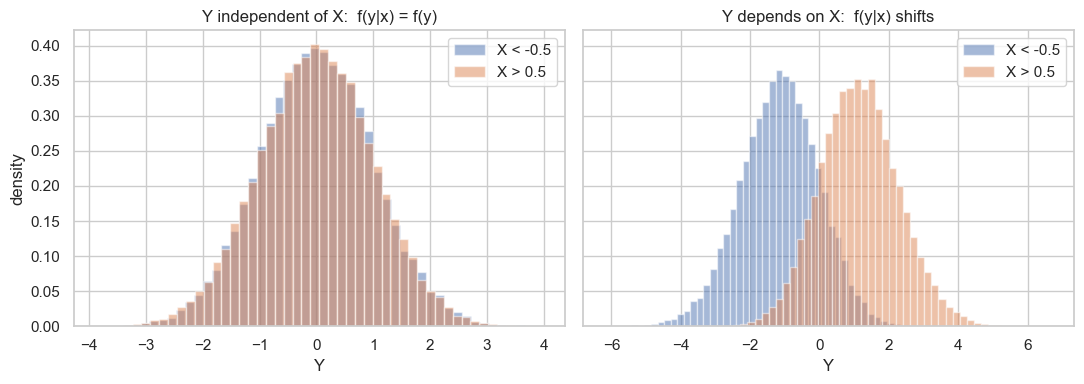

In [10]:
np.random.seed(201)
n = 100_000
X = np.random.normal(0, 1, n)
Y_indep = np.random.normal(0, 1, n)          # does not use X
Y_dep   = X + np.random.normal(0, 1, n)      # shifts with X

low  = X < -0.5      # slice where X is small
high = X >  0.5      # slice where X is large

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, Yv, title in [(ax[0], Y_indep, "Y independent of X:  f(y|x) = f(y)"),
                     (ax[1], Y_dep,   "Y depends on X:  f(y|x) shifts")]:
    a.hist(Yv[low],  bins=50, density=True, alpha=0.5, label="X < -0.5")
    a.hist(Yv[high], bins=50, density=True, alpha=0.5, label="X > 0.5")
    a.set_title(title); a.set_xlabel("Y"); a.legend()
ax[0].set_ylabel("density")
plt.tight_layout(); plt.show()

### "Uncorrelated" does not imply "independent"

The arrow only runs one way. Covariance measures linear co-movement, so two variables can be
perfectly *dependent* yet have zero covariance. The classic example is $Y = X^2$ with $X$ symmetric
around $0$: as $X$ moves away from $0$ in either direction $Y$ rises, so there is no net *linear* trend
— but $Y$ is completely determined by $X$. Independence is the stronger condition.

Cov(X, X^2) = -0.0000   (about 0, so X and Y are uncorrelated)
...yet Y is completely determined by X, so they are NOT independent.


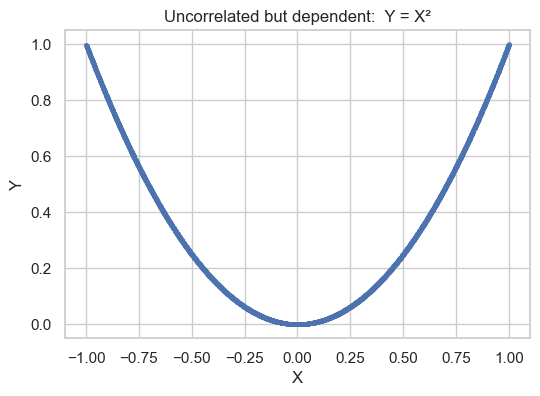

In [11]:
np.random.seed(201)
X = np.random.uniform(-1, 1, 10_000)
Y = X ** 2                              # Y is a deterministic function of X

print(f"Cov(X, X^2) = {np.cov(X, Y)[0, 1]:+.4f}   (about 0, so X and Y are uncorrelated)")
print("...yet Y is completely determined by X, so they are NOT independent.")

plt.figure(figsize=(6, 4))
plt.scatter(X, Y, s=6, alpha=0.3)
plt.title("Uncorrelated but dependent:  Y = X\u00b2")
plt.xlabel("X"); plt.ylabel("Y")
plt.show()

### Functions of independent variables are independent

If $X \perp Y$, then $f(X) \perp g(Y)$ for *any* functions $f$ and $g$ — so their covariance stays at
zero no matter how we transform each variable. 

In [12]:
np.random.seed(7)
n = 200_000
X = np.random.normal(0, 1, n)
Y = np.random.normal(0, 1, n)          # independent of X

print(f"Cov(X, Y)        = {np.cov(X, Y)[0, 1]:+.4f}")
print(f"Cov(sin X, Y^2)  = {np.cov(np.sin(X), Y ** 2)[0, 1]:+.4f}")
print("Because X \u22a5 Y, transforming each side keeps the covariance near 0.")

Cov(X, Y)        = +0.0031
Cov(sin X, Y^2)  = +0.0008
Because X ⊥ Y, transforming each side keeps the covariance near 0.


## 1.3 The Normal distribution

$X$ is **Normally distributed** with mean $\mu$ and variance $\sigma^2$, written
$X \sim \mathcal{N}(\mu, \sigma^2)$, if it has the bell-shaped density

$$
f(x) = \frac{1}{\sqrt{2\pi}\,\sigma}\, e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}.
$$

(No need to memorize the formula.) The Normal describes many naturally occurring quantities. Its shape is
fixed; only the *center* ($\mu$) and *width* ($\sigma$) change.

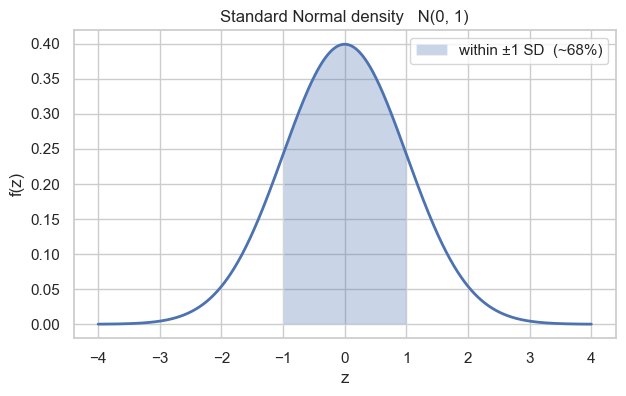

In [13]:
z = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(z, 0, 1)          # standard Normal density

plt.figure(figsize=(7, 4))
plt.plot(z, pdf, lw=2)
plt.fill_between(z, pdf, where=(z > -1) & (z < 1), alpha=0.3, label="within \u00b11 SD  (~68%)")
plt.title("Standard Normal density   N(0, 1)")
plt.xlabel("z"); plt.ylabel("f(z)"); plt.legend()
plt.show()

### The 68–95–99.7 rule

For **any** Normal, the fraction within $1$, $2$, and $3$ standard deviations of the mean is always
about $68\%$, $95\%$, and $99.7\%$. Let's confirm empirically with a million draws and compare to the
exact figures from `scipy`.

In [14]:
np.random.seed(201)
sample = np.random.normal(0, 1, 1_000_000)

print(f"{'within':>9} | {'empirical':>10} | {'exact':>8}")
for k in (1, 2, 3):
    emp   = np.mean(np.abs(sample) < k)
    exact = stats.norm.cdf(k) - stats.norm.cdf(-k)
    print(f"{k:>6} SD | {emp:>10.4f} | {exact:>8.4f}")

   within |  empirical |    exact
     1 SD |     0.6825 |   0.6827
     2 SD |     0.9546 |   0.9545
     3 SD |     0.9974 |   0.9973


### Standardizing, and the CDF $\Phi$

Any Normal becomes the **standard Normal** $\mathcal{N}(0,1)$ by subtracting the mean and dividing by
the standard deviation:

$$
Z = \frac{X - \mu}{\sigma} \sim \mathcal{N}(0, 1).
$$

A value of $Z$ is simply "how many standard deviations from the mean" — $z = 1$ means one SD above the
mean, $z = -2$ means two below. The standard-Normal CDF is $\Phi(z) = P(Z \le z)$. Using the male-height
numbers from the slide ($\mu = 178.4$ cm, $\sigma \approx 7.6$ cm): *what fraction of adult men are
taller than $190$ cm?*

In [15]:
mu, sigma = 178.4, 7.6                  # adult male height (cm), from the lecture slide
heights = np.random.normal(mu, sigma, 100_000)

z = (heights - mu) / sigma              # standardize
print(f"Standardized mean = {z.mean():+.3f}   (about 0)")
print(f"Standardized SD   = {z.std():.3f}    (about 1)")

z_190 = (190 - mu) / sigma
print(f"\nz-score of 190 cm = {z_190:.2f}")
print(f"P(height > 190)   = 1 - \u03a6({z_190:.2f}) = {1 - stats.norm.cdf(z_190):.3f}")

Standardized mean = -0.001   (about 0)
Standardized SD   = 1.001    (about 1)

z-score of 190 cm = 1.53
P(height > 190)   = 1 - Φ(1.53) = 0.063


Standardizing only shifts and rescales — it never changes the shape. The picture below shows the
raw heights and their standardized version side by side; the second lands right on top of the $N(0,1)$
curve.

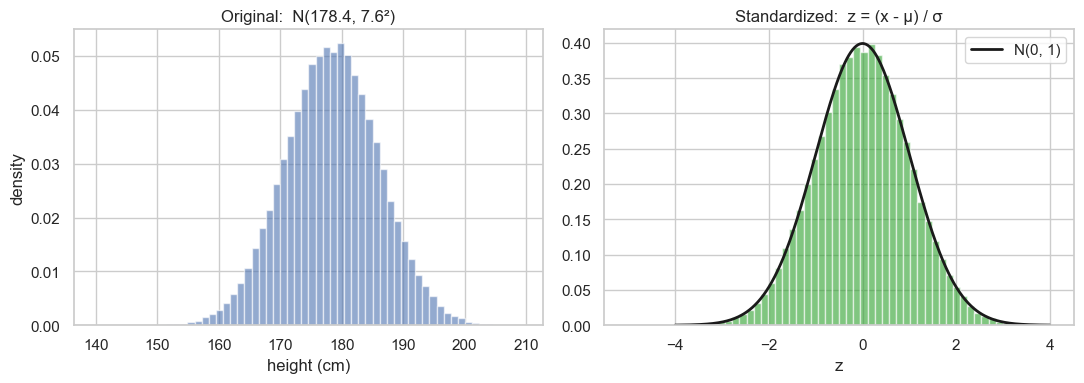

In [16]:
np.random.seed(201)
raw = np.random.normal(178.4, 7.6, 100_000)   # male heights again
std = (raw - raw.mean()) / raw.std()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(raw, bins=60, density=True, alpha=0.6)
ax[0].set_title("Original:  N(178.4, 7.6\u00b2)"); ax[0].set_xlabel("height (cm)"); ax[0].set_ylabel("density")

ax[1].hist(std, bins=60, density=True, alpha=0.6, color="tab:green")
zz = np.linspace(-4, 4, 400)
ax[1].plot(zz, stats.norm.pdf(zz), "k", lw=2, label="N(0, 1)")
ax[1].set_title("Standardized:  z = (x - \u03bc) / \u03c3"); ax[1].set_xlabel("z"); ax[1].legend()
plt.tight_layout(); plt.show()

# Part 2 — Revisiting the All-Causes Model

## 2.1 Definition

The all-causes model writes an outcome as a function of the state of the world and everything else:

$$
Y(S, U),
$$

where $Y$ is the outcome, $S$ is the treatment (we take it binary: $1$ = treated, $0$ = not), and
$U$ collects all other factors that influence $Y$. Since $S$ and $U$ are themselves random, $Y(S,U)$ is
a random variable — a function of random variables. Our causal quantities of interest are
expectations of the individual treatment effect$Y(1) - Y(0)$:

$$
\begin{aligned}
\text{ATE} &= E[\,Y(1) - Y(0)\,] & &\text{(everyone)}\\
\text{ATT} &= E[\,Y(1) - Y(0)\mid S = 1\,] & &\text{(the treated)}\\
\text{ATU} &= E[\,Y(1) - Y(0)\mid S = 0\,] & &\text{(the untreated)}
\end{aligned}
$$

Because expectation is **linear**, each estimand splits into two pieces — and this "breaking apart" is
what makes them estimable:

$$
\text{ATE} = E[Y(1)] - E[Y(0)], \quad
\text{ATT} = E[Y(1)\mid S{=}1] - E[Y(0)\mid S{=}1], \quad
\text{ATU} = E[Y(1)\mid S{=}0] - E[Y(0)\mid S{=}0].
$$

By the law of iterated expectations, the ATE is a probability-weighted blend of the other two:
$\text{ATE} = \text{ATT}\cdot P(S=1) + \text{ATU}\cdot P(S=0)$. These three generally **differ**, because
the people who take treatment may have systematically different effects than those who don't.

## 2.2 A worked example: college and income

Following the lecture, let

- $Y$ = income (continuous),
- $S$ = college attendance ($1$ = went to college),
- $U$ = family wealth ($1$ = wealthy family).

Family wealth is a common cause of both: wealthier families make college more likely *and* raise
income directly. That makes $U$ a **confounder**, drawn below as a DAG.

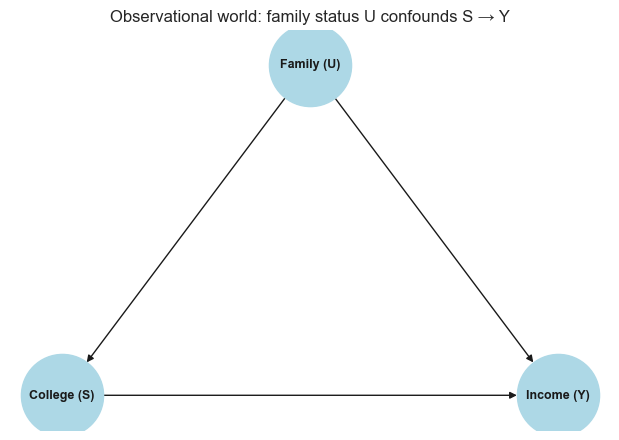

In [17]:
G = nx.DiGraph()
G.add_edges_from([("Family (U)", "College (S)"),
                  ("Family (U)", "Income (Y)"),
                  ("College (S)", "Income (Y)")])
pos = {"Family (U)": (0, 1), "College (S)": (-1, 0), "Income (Y)": (1, 0)}

plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_size=3500, node_color="lightblue",
        font_size=9, font_weight="bold", arrows=True)
plt.title("Observational world: family status U confounds S \u2192 Y")
plt.show()

### Generating the data

Because this is a simulation, we can do something impossible in real life: write down both potential
outcomes for every person — the income they *would* earn with college, $Y(1)$, and without it, $Y(0)$.
Two deliberate features:

- Wealthy families are more likely to attend college — this is the **confounding**.
- People who actually attend get a higher $Y(0)$ (a $+10{,}000$ term on `college`), so college-goers
  would have earned more *even without* college. This is **selection**, and it is what biases the naive
  comparison.

In [18]:
np.random.seed(42)
n = 1000

# U: family status (1 = wealthy, 0 = not). A common cause of both S and Y.
family = np.random.binomial(1, 0.4, n)

# S: college attendance. Wealthy families are more likely to attend (the confounding).
college = np.random.binomial(1, 0.7 * family + 0.3 * (1 - family), n)

# Potential outcomes (income). We can see BOTH only because this is a simulation.
noise = np.random.normal(0, 5000, n)
Y1 = 50000 + 30000 + 20000 * family + noise                     # income WITH college   = Y(1)
Y0 = 50000 +         20000 * family + 10000 * college + noise   # income WITHOUT         = Y(0)

# What we actually observe: the outcome matching each person's real choice.
Y_obs = np.where(college == 1, Y1, Y0)

df = pd.DataFrame({"family": family, "college": college, "Y1": Y1, "Y0": Y0, "Y_obs": Y_obs})
df.head()

,family,college,Y1,Y0,Y_obs
0,0,0,75610.087066,45610.087066,45610.087066
1,1,1,95865.598230,75865.598230,95865.598230
2,1,0,98867.605540,68867.605540,68867.605540
3,0,1,81836.827534,61836.827534,81836.827534
4,0,1,84567.923131,64567.923131,84567.923131


### The true effects

With both potential outcomes in hand, the estimands are just averages of $Y(1) - Y(0)$.

In [19]:
effect = df.Y1 - df.Y0                       # individual treatment effect Y(1) - Y(0)

ATE = effect.mean()
ATT = effect[df.college == 1].mean()
ATU = effect[df.college == 0].mean()

print(f"True ATE = E[Y(1) - Y(0)]         = {ATE:9.1f}")
print(f"True ATT = E[Y(1) - Y(0) | S = 1] = {ATT:9.1f}")
print(f"True ATU = E[Y(1) - Y(0) | S = 0] = {ATU:9.1f}")

True ATE = E[Y(1) - Y(0)]         =   25560.0
True ATT = E[Y(1) - Y(0) | S = 1] =   20000.0
True ATU = E[Y(1) - Y(0) | S = 0] =   30000.0


### Breaking apart the expectations

$E[Y(1)]$ rebuilt from its two conditional pieces should match the direct average, and the ATE should
equal the probability-weighted blend of ATT and ATU.

In [20]:
pS1 = df.college.mean()          # P(S = 1)
pS0 = 1 - pS1

# Rebuild E[Y(1)] from conditional pieces (law of iterated expectations)
EY1     = df.Y1.mean()
EY1_lie = df.Y1[df.college == 1].mean() * pS1 + df.Y1[df.college == 0].mean() * pS0
print(f"E[Y(1)]                 = {EY1:9.1f}")
print(f"weighted conditionals   = {EY1_lie:9.1f}   (LIE, matches \u2713)")

# ATE as a blend of ATT and ATU
print(f"\nATE                       = {ATE:9.1f}")
print(f"ATT*P(S=1) + ATU*P(S=0)   = {ATT * pS1 + ATU * pS0:9.1f}   (matches \u2713)")

E[Y(1)]                 =   87804.6
weighted conditionals   =   87804.6   (LIE, matches ✓)

ATE                       =   25560.0
ATT*P(S=1) + ATU*P(S=0)   =   25560.0   (matches ✓)


## 2.3 Why the naive comparison is biased

In real data we only see $Y_{\text{obs}}$. The tempting move is to compare average income of
college-goers vs. non-goers, $\widehat{\Delta} = E[Y \mid S=1] - E[Y \mid S=0]$. But this mixes the
causal effect with the fact that college-goers were already different, so it overshoots the ATE.

In [21]:
naive = df.Y_obs[df.college == 1].mean() - df.Y_obs[df.college == 0].mean()

print(f"Naive difference  E[Y|S=1] - E[Y|S=0] = {naive:9.1f}")
print(f"True ATE                              = {ATE:9.1f}")
print(f"Selection bias                        = {naive - ATE:+9.1f}")

Naive difference  E[Y|S=1] - E[Y|S=0] =   37639.9
True ATE                              =   25560.0
Selection bias                        =  +12079.9


### Decomposing the bias

We can say exactly what the naive number measures. Add and subtract $E[Y(0)\mid S=1]$:

$$
\underbrace{E[Y\mid S=1] - E[Y\mid S=0]}_{\text{naive}}
= \underbrace{E[Y(1)\mid S=1] - E[Y(0)\mid S=1]}_{\text{ATT}}
+ \underbrace{E[Y(0)\mid S=1] - E[Y(0)\mid S=0]}_{\text{selection bias}}.
$$

**Selection bias** is the difference in the *untreated* potential outcome between the two groups — how
much more college-goers would have earned *even without* college. It is zero exactly when the groups are
comparable, which is what $S \perp U$ guarantees.

In [22]:
# Naive = ATT + selection bias
sel_bias = df.Y0[df.college == 1].mean() - df.Y0[df.college == 0].mean()

print(f"Naive difference      = {naive:9.1f}")
print(f"ATT                   = {ATT:9.1f}")
print(f"Selection bias        = {sel_bias:9.1f}")
print(f"ATT + selection bias  = {ATT + sel_bias:9.1f}   (matches naive \u2713)")

Naive difference      =   37639.9
ATT                   =   20000.0
Selection bias        =   17639.9
ATT + selection bias  =   37639.9   (matches naive ✓)


## 2.4 Identification

Most identification strategies rely on an assumption like $S \perp U$
(treatment independent of the other causes). When it holds, conditioning on $S$ tells us nothing extra
about the potential outcomes, so

$$
E[Y(1)\mid S=1] = E[Y(1)], \qquad E[Y(0)\mid S=0] = E[Y(0)],
$$

the selection-bias term vanishes, and the naive difference collapses to the ATE. The cleanest way to
*force* $S \perp U$ is to assign treatment at random — a coin flip that ignores family status entirely.

In [23]:
# Randomly assign college by a coin flip, ignoring family status -> S is independent of U.
np.random.seed(247)
S_rand = np.random.binomial(1, 0.5, n)
Y_rand = np.where(S_rand == 1, df.Y1, df.Y0)     # reveal the matching potential outcome

naive_rand = Y_rand[S_rand == 1].mean() - Y_rand[S_rand == 0].mean()

print(f"corr(college, family)  observational = {np.corrcoef(df.college, df.family)[0, 1]:+.3f}")
print(f"corr(college, family)  randomized    = {np.corrcoef(S_rand, df.family)[0, 1]:+.3f}   (about 0: S \u22a5 U)")
print()
print(f"Naive difference under randomization = {naive_rand:9.1f}")
print(f"True ATE                             = {ATE:9.1f}   (matches \u2713)")

corr(college, family)  observational = +0.373
corr(college, family)  randomized    = +0.001   (about 0: S ⊥ U)

Naive difference under randomization =   25582.9
True ATE                             =   25560.0   (matches ✓)


/Users/ananyadevraj/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8869 (\N{UP TACK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


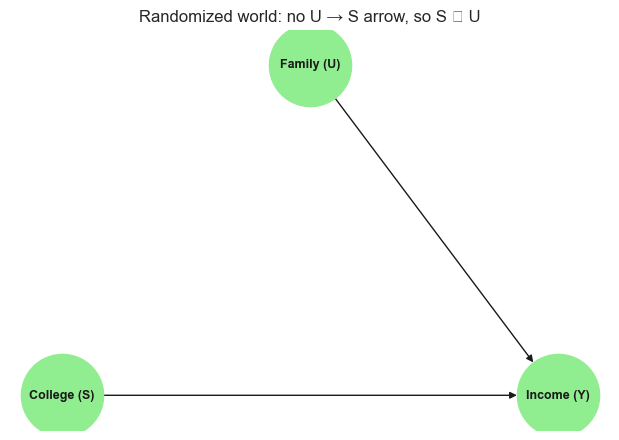

In [24]:
# The DAG for the randomized world: the U -> S arrow is gone.
G2 = nx.DiGraph()
G2.add_edges_from([("Family (U)", "Income (Y)"),
                   ("College (S)", "Income (Y)")])
pos2 = {"Family (U)": (0, 1), "College (S)": (-1, 0), "Income (Y)": (1, 0)}

plt.figure(figsize=(6, 4))
nx.draw(G2, pos2, with_labels=True, node_size=3500, node_color="lightgreen",
        font_size=9, font_weight="bold", arrows=True)
plt.title("Randomized world: no U \u2192 S arrow, so S \u22a5 U")
plt.show()

## 2.5 If we can't randomize: condition on what we observe

When randomization isn't possible but we *observe* the confounder, we can at least compare college-goers
vs. non-goers **within** each level of family status, holding $U$ fixed.

In [25]:
for u in (0, 1):
    grp = df[df.family == u]
    a = grp.Y_obs[grp.college == 1].mean() - grp.Y_obs[grp.college == 0].mean()
    print(f"Association within family = {u}: {a:9.1f}")

Association within family = 0:   30308.1
Association within family = 1:   30553.7


Conditioning on family status removes the part of the bias that flows through $U$ — each within-group
number is much closer to a genuine causal effect than the pooled naive figure. A gap to the ATE still
remains here, because our simulation also included selection that family status alone doesn't capture
(the $+10{,}000$ term). Handling *that* leftover confounding is what later lectures on adjustment and
identification are for.

# Part 3 — Statistics (Review 1)

## 3.1 From probability to statistics

So far we have worked in **probability**: we *assume* the distribution $F$ of a random variable is known,
and reason forward about what data drawn from it will look like — e.g. computing $P(a \le \bar X \le b)$.
Knowledge of the population tells us about the samples.

**Statistics runs that arrow backwards.** Now $F$ is *unknown*. We only observe a finite batch of realized
outcomes $x_1, \dots, x_n$, and the job is to reason *from the data back to the population* — to estimate
or infer features of the unknown $F$.

Why this matters here: in Part 2 we *defined* the causal parameters (ATE, ATT, ATU) as expectations —
features of a distribution we don't actually know. Statistics lets us **estimate
those parameters from a finite sample** and say how much to trust the answer.

One standing assumption throughout: the data are **i.i.d.** — *independent and identically distributed*,
written $X_1, \dots, X_n \overset{\text{iid}}{\sim} X$. "Identically distributed" means each $X_i$ is a
draw from the same distribution as $X$; "independent" means the draws don't influence one another
(Part 1).

## 3.2 Estimators

We want to learn a parameter $\theta$ of the population — say the mean $\theta = E[X]$. An **estimator**
is anything that turns a sample into a guess for $\theta$:

$$\hat\theta_n = \hat\theta_n(X_1, \dots, X_n).$$

Reading the notation: the hat ($\hat{\phantom{x}}$) marks this as an *estimate* of $\theta$ rather
than the true value, and the subscript **$n$** records the sample size the guess is built from.

The single most important idea in this section:

- the parameter $\theta$ is a **fixed number** — the population has one true mean; we just don't know it.
- the estimator $\hat\theta_n$ is a **random variable** — it is a function of the *random* sample, so
  before we collect data it has a whole distribution of possible values. It collapses to one number only
  once we plug in an actual observed sample. (Compare a conditional expectation: also a random variable
  until you fix what you condition on.)

The natural estimator for the mean is the **sample mean**:

$$\bar X_n = \frac1n \sum_{i=1}^n X_i.$$
 The next
three subsections study three features of that distribution: its center (**bias**), its spread
(**variance**), and its long-run behavior (**consistency**).

## 3.3 Bias — is the estimator centered on the truth?

**Bias** asks whether the estimator is right *on average*, where "on average" means averaged over all the
samples we might have drawn:

$$\text{Bias}[\hat\theta_n] = E[\hat\theta_n] - \theta.$$

If $\text{Bias}[\hat\theta_n] = 0$ then $E[\hat\theta_n] = \theta$ and we call the estimator **unbiased** —
its sampling distribution is centered exactly on the true value. (It can still miss on any *single*
sample; unbiasedness is about the center of the distribution, not one draw.)

The sample mean is unbiased for $E[X]$. Here is the argument one step at a time:

$$
\begin{aligned}
E[\bar X_n]
&= E\!\left[\tfrac1n \textstyle\sum_{i=1}^n X_i\right]
   && \text{(definition of } \bar X_n) \\[2pt]
&= \tfrac1n \textstyle\sum_{i=1}^n E[X_i]
   && \text{(linearity: the mean of a sum is the sum of the means)} \\[2pt]
&= \tfrac1n \textstyle\sum_{i=1}^n E[X]
   && \text{(identically distributed: every } X_i \text{ has mean } E[X]) \\[2pt]
&= \tfrac1n \cdot n \cdot E[X] = E[X]
   && \text{(the sum is } n \text{ copies of } E[X]).
\end{aligned}
$$

So $\text{Bias}[\bar X_n] = E[X] - E[X] = 0$.

Notice the sample size $n$ cancelled — it never mattered. Bias is a **finite-sample property**: it holds
at *every* $n$, not only for large samples. In fact the sample mean is unbiased even for a sample of
**one**, because $E[X_1] = E[X]$. The simulation below confirms this by averaging the sample mean over
many independent samples and checking that the average lands on the true mean $3.5$.

In [26]:
# Average the sample mean over many samples: it should land on the true mean.
np.random.seed(201)
true_mean = 3.5                       # E[X] for a fair die
num_sims  = 10_000

for n in (1, 10, 100):
    sample_means = [np.random.randint(1, 7, n).mean() for _ in range(num_sims)]
    print(f"n = {n:>3}:  average of sample means = {np.mean(sample_means):.3f}   "
          f"bias = {np.mean(sample_means) - true_mean:+.3f}")

print("\nThe sample mean is unbiased at every n \u2014 even n = 1.")

n =   1:  average of sample means = 3.480   bias = -0.020
n =  10:  average of sample means = 3.496   bias = -0.004
n = 100:  average of sample means = 3.499   bias = -0.001

The sample mean is unbiased at every n — even n = 1.


## 3.4 Variance — how much does the estimate bounce around?

Unbiasedness alone isn't enough. Two unbiased estimators can differ in how far a *typical* sample
throws them from the truth. That spread is the **variance of the estimator**,
$\operatorname{Var}(\hat\theta_n)$ — a smaller variance means we're less likely to draw an estimate far
from $\theta$, so between two unbiased estimators we prefer the one with less variance.

For the sample mean we can compute the variance exactly. Watch where each i.i.d. assumption enters:

$$
\begin{aligned}
\operatorname{Var}(\bar X_n)
&= \operatorname{Var}\!\left(\tfrac1n \textstyle\sum_{i=1}^n X_i\right) \\[2pt]
&= \tfrac{1}{n^2}\,\operatorname{Var}\!\left(\textstyle\sum_{i=1}^n X_i\right)
   && \text{(constants pull out squared: } \operatorname{Var}(cW)=c^2\operatorname{Var}(W)) \\[2pt]
&= \tfrac{1}{n^2}\left(\textstyle\sum_{i=1}^n \operatorname{Var}(X_i) + 2\sum_{i<j}\operatorname{Cov}(X_i,X_j)\right)
   && \text{(variance of a sum, in general)} \\[2pt]
&= \tfrac{1}{n^2}\textstyle\sum_{i=1}^n \operatorname{Var}(X_i)
   && \text{(independence: every covariance term is } 0) \\[2pt]
&= \tfrac{1}{n^2}\textstyle\sum_{i=1}^n \operatorname{Var}(X)
   && \text{(identically distributed: each variance is } \operatorname{Var}(X)) \\[2pt]
&= \tfrac{1}{n^2}\cdot n \cdot \operatorname{Var}(X) = \frac{\operatorname{Var}(X)}{n}.
\end{aligned}
$$

$\operatorname{Var}(\bar X_n) = \dfrac{\operatorname{Var}(X)}{n}$, says the spread of the
sample mean shrinks in proportion to $1/n$. Two readings:

- More data $\Rightarrow$ tighter estimates. Because the *standard deviation* is
  $\text{SD}(\bar X_n) = \sigma/\sqrt{n}$, quadrupling the sample halves the typical error.
- This is *why averaging works*: independent noise partly cancels, and the more terms you average, the
  more of it cancels.

The code checks $\operatorname{Var}(\bar X_n) \approx \operatorname{Var}(X)/n$ at several sample sizes.

In [27]:
np.random.seed(201)
var_X = np.var(np.random.randint(1, 7, 1_000_000))     # Var(X) for a die (about 2.917)
print(f"Var(X) for a die = {var_X:.3f}\n")

print(f"{'n':>5} | {'Var(sample mean) empirical':>26} | {'Var(X)/n theory':>16}")
for n in (5, 20, 100, 500):
    sms = [np.random.randint(1, 7, n).mean() for _ in range(20_000)]
    print(f"{n:>5} | {np.var(sms):>26.4f} | {var_X / n:>16.4f}")

Var(X) for a die = 2.916

    n | Var(sample mean) empirical |  Var(X)/n theory
    5 |                     0.5931 |           0.5832
   20 |                     0.1476 |           0.1458
  100 |                     0.0291 |           0.0292
  500 |                     0.0058 |           0.0058


## 3.5 Consistency and the Weak Law of Large Numbers

Bias and variance are **finite-sample** properties — true at any fixed $n$. **Consistency** is a
different, **large-sample** concept: as we gather more data, the estimator homes in on the true value.
Formally, $\hat\theta_n$ is **consistent** if for *any* tolerance $\varepsilon > 0$,

$$P\big(|\hat\theta_n - \theta| > \varepsilon\big) \;\longrightarrow\; 0 \qquad \text{as } n \to \infty.$$

In words: pick any margin you like — a penny, a millimeter — and the probability that the estimate is off
by *more* than that margin drops to zero as the sample grows. The estimate may not ever be exact; being
noticeably wrong just becomes unlikely.

The **Weak Law of Large Numbers (WLLN)** is the flagship case: the sample mean is consistent for $E[X]$,

$$P\big(|\bar X_n - E[X]| > \varepsilon\big) \to 0.$$

Two things worth stressing:

- We can already *see why* from Section 3.4. Since $\operatorname{Var}(\bar X_n) = \operatorname{Var}(X)/n \to 0$,
  the sampling distribution keeps tightening around $E[X]$, leaving no room to be far off.
- The WLLN asks almost nothing of the distribution — only i.i.d. draws with $E[X^2] < \infty$ (a finite
  variance). We do **not** need to know the shape of $F$.

The plot draws a sample of each size $n = 1, 2, \dots, 1000$ and shows its sample mean. For small
$n$ the means swing; as $n$ grows they are squeezed into narrow band around the true
mean $3.5$.

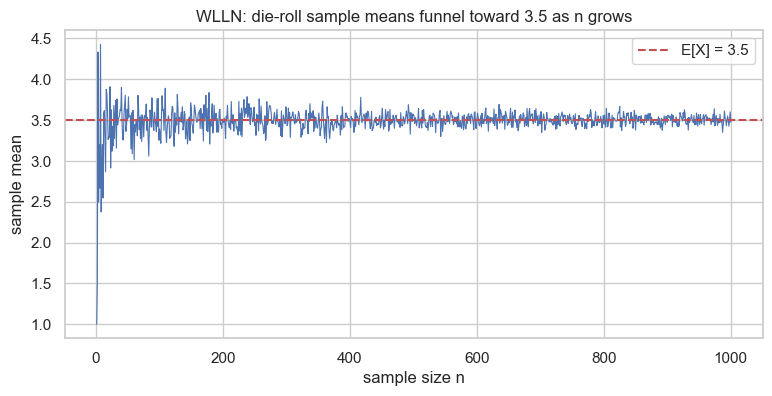

In [28]:
np.random.seed(201)
sizes = np.arange(1, 1001)
means = [np.random.randint(1, 7, n).mean() for n in sizes]   # a fresh sample of size n at each n

plt.figure(figsize=(9, 4))
plt.plot(sizes, means, lw=0.8)
plt.axhline(3.5, color="r", ls="--", label="E[X] = 3.5")
plt.title("WLLN: die-roll sample means funnel toward 3.5 as n grows")
plt.xlabel("sample size n"); plt.ylabel("sample mean"); plt.legend()
plt.show()

## 3.6 The Central Limit Theorem

The sample mean $\bar X_n$ is itself random — a different sample gives a different value — so it has its
own distribution, called the **sampling distribution**. We already know two of its features: its center
is $E[X]$ (Section 3.3) and its standard deviation is $\sigma/\sqrt{n}$ (Section 3.4). The **Central Limit
Theorem (CLT)** gives us the third: its *shape*.

**The idea in one line:** take any population, sample it, and average. Those averages pile up into a
**bell curve** once $n$ is reasonably large — no matter what the raw data look like (a flat die, skewed
incomes, anything).

Formally, for i.i.d. $X$ with finite variance,

$$\bar X_n \;\approx\; \mathcal{N}\!\left(E[X],\ \frac{\sigma^2}{n}\right) \qquad \text{for large } n.$$

**Why the formula looks the way it does — it's just a z-score.** Standardizing (Section 1.3) means
$Z = \dfrac{\text{value} - \text{its mean}}{\text{its SD}}$. Apply that to the sample mean, whose mean is
$E[X]$ and whose SD is $\sigma/\sqrt{n}$:

$$Z = \frac{\bar X_n - E[X]}{\sigma/\sqrt{n}} = \frac{\sqrt{n}\,\big(\bar X_n - E[X]\big)}{\sigma}
\;\longrightarrow\; \mathcal{N}(0, 1).$$

Dividing by $\sigma/\sqrt{n}$ is the same as multiplying by $\sqrt{n}/\sigma$ — that's where the
$\sqrt{n}$ comes from. "Standardize the sample
mean,"* and the result is a standard Normal = CLT formula.

**Why multiply by $\sqrt{n}$ at all?** The error $\bar X_n - E[X]$ shrinks to $0$ as $n$ grows (the WLLN),
so plotting it alone would just show a spike. That error has SD $\sigma/\sqrt{n}$, so multiplying by
$\sqrt{n}$ exactly cancels the shrinking and keeps the spread fixed — a zoom lens that holds the picture
at a constant size so its bell shape can appear.

The next cell shows this for die rolls at $n = 1, 5, 30, 100, 1000$: we compute the standardized error
many times (using the die's known $\sigma = \sqrt{35/12}$) and histogram it against the $N(0,1)$ curve.

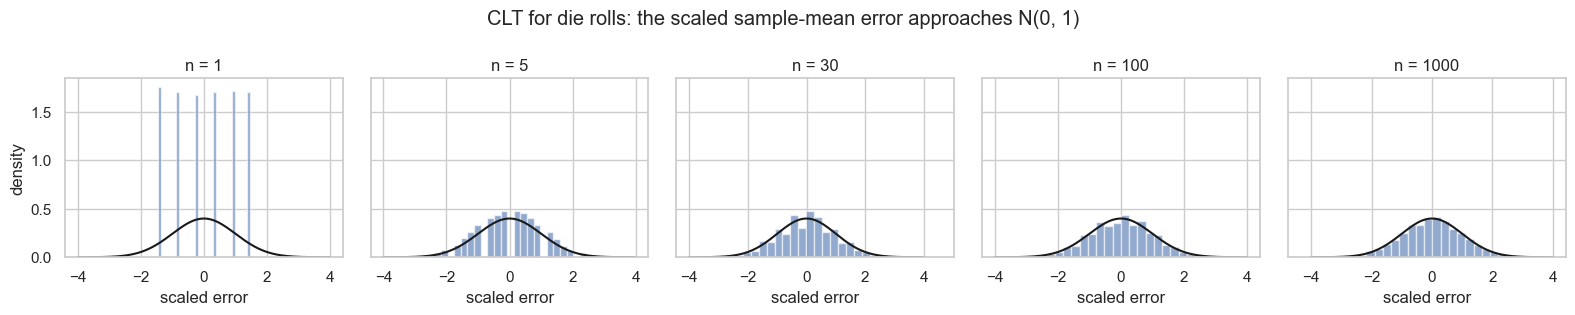

In [29]:
np.random.seed(201)
sigma = np.sqrt(35 / 12)              # known SD of a fair die
sizes = [1, 5, 30, 100, 1000]
num_samples = 20_000
zz = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for ax, n in zip(axes, sizes):
    samples = np.random.randint(1, 7, size=(num_samples, n))
    Z = np.sqrt(n) * (samples.mean(axis=1) - 3.5) / sigma     # standardized error
    ax.hist(Z, bins=30, density=True, alpha=0.6)
    ax.plot(zz, stats.norm.pdf(zz), "k", lw=1.5)
    ax.set_title(f"n = {n}"); ax.set_xlabel("scaled error")
axes[0].set_ylabel("density")
plt.suptitle("CLT for die rolls: the scaled sample-mean error approaches N(0, 1)")
plt.tight_layout(); plt.show()

At $n = 1$ the "average" is just a single die roll, so the histogram is six flat bars. As $n$ grows the bars fill in and smooth out, and by $n = 30$ it already looks Normal. The die is
flat and discrete, yet the *average's* error becomes Normal — that's the whole point, and it's what lets
us use Normal-based confidence intervals and tests later.

### The CLT doesn't care what the data look like

To show it isn't a fluke of the die, repeat with a strongly skewed distribution — an Exponential (a
long right tail). Single draws look nothing like a bell, but the sample mean's standardized error still
becomes Normal as $n$ grows. 

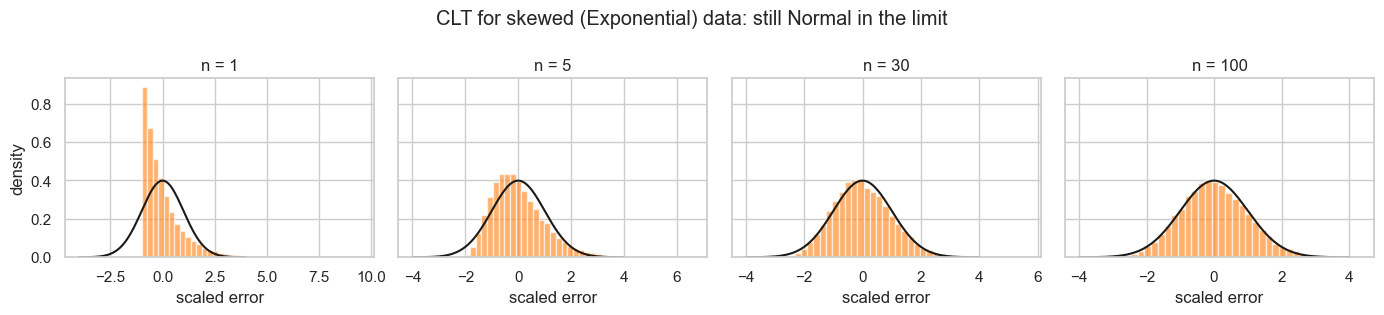

In [30]:
np.random.seed(201)
sizes = [1, 5, 30, 100]
num_samples = 20_000
zz = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, n in zip(axes, sizes):
    samples = np.random.exponential(1.0, size=(num_samples, n))   # mean 1, SD 1, very skewed
    Z = np.sqrt(n) * (samples.mean(axis=1) - 1.0) / 1.0
    ax.hist(Z, bins=40, density=True, alpha=0.6, color="tab:orange")
    ax.plot(zz, stats.norm.pdf(zz), "k", lw=1.5)
    ax.set_title(f"n = {n}"); ax.set_xlabel("scaled error")
axes[0].set_ylabel("density")
plt.suptitle("CLT for skewed (Exponential) data: still Normal in the limit")
plt.tight_layout(); plt.show()

## 3.7 Estimating the variance and using it in CLT

The CLT formula divides by the true standard deviation $\sigma$ — but in real life we don't know
$\sigma$. So we estimate it from the data with the **sample variance**:

$$\hat\sigma_n^2 = \frac{1}{n-1} \sum_{i=1}^n (X_i - \bar X_n)^2.$$

Two things students always ask:

- **Why measure spread around $\bar X_n$?** We don't know the true mean, so we use the sample mean in its
  place.
- **Why divide by $n - 1$, not $n$?** Measuring spread around the sample's *own* average makes the
  deviations come out a little too small (the data sit closest to their own mean). Dividing by $n - 1$
  instead of $n$ bumps it up just enough so that $\hat\sigma_n^2$ is unbiased for $\operatorname{Var}(X)$.

Swapping $\hat\sigma_n$ in for $\sigma$ gives the **normalized CLT**, which still lands on the standard
Normal:

$$Z = \frac{\sqrt{n}\,\big(\bar X_n - E[X]\big)}{\hat\sigma_n} \;\longrightarrow\; \mathcal{N}(0, 1).$$


In [40]:
np.random.seed(201)
var_X = 35 / 12                       # true Var of a fair die
n = 50
sample = np.random.randint(1, 7, n)

print(f"True Var(X)            = {var_X:.4f}")
print(f"1/n     * SS (ddof=0)  = {sample.var(ddof=0):.4f}   (biased low)")
print(f"1/(n-1) * SS (ddof=1)  = {sample.var(ddof=1):.4f}   <- the sample variance")

many = [np.random.randint(1, 7, n).var(ddof=1) for _ in range(20_000)]
print(f"\nAverage sample variance over 20k samples = {np.mean(many):.4f}  (about Var(X), so unbiased)")

True Var(X)            = 2.9167
1/n     * SS (ddof=0)  = 3.3184   (biased low)
1/(n-1) * SS (ddof=1)  = 3.3861   <- the sample variance

Average sample variance over 20k samples = 2.9154  (about Var(X), so unbiased)


---

## Summary

- **Conditional variance** is a function of $X$; the definition and $E[Y^2\mid X] - (E[Y\mid X])^2$ are
  provably equal.
- **Independence** $\Rightarrow$ zero covariance (via $E[XY] = E[X]E[Y]$), but not the reverse —
  covariance only sees *linear* co-movement.
- Standardizing sends any $\mathcal{N}(\mu, \sigma^2)$ to $\mathcal{N}(0, 1)$; the 68–95–99.7 rule is
  built in.
- **ATE / ATT / ATU** differ when effects vary across who takes treatment; the naive comparison equals
  ATT + selection bias, and $S \perp U$ (delivered by randomization) is what lets association identify
  causation.
- An **estimator** is a random variable. The sample mean is **unbiased** ($E[\bar X_n] = E[X]$) with
  variance $\operatorname{Var}(X)/n$, is **consistent** by the WLLN, and by the **CLT** its scaled error
  is asymptotically standard Normal.

# Part 4 — Exercises

Work these in section. Pencil-and-paper parts can go in a markdown cell; coding parts have a starter
cell with a `# YOUR CODE HERE` marker. Reuse the helper functions defined above
(`cond_mean`, `cond_var_definition`, ...).

### A. Conditional variance

**A1 (pencil).** Using the same "pull the constant out" trick from Section 1.1, show that for constants
$a$ and $b$, $\operatorname{Var}(aY + b \mid X) = a^2 \operatorname{Var}(Y \mid X)$.

**A2 (code).** Below, the noise standard deviation is $\sqrt{X}$. *Predict* $\operatorname{Var}(Y\mid X=x)$
as a formula in $x$, then verify it for $x = 1,\dots,5$.

In [32]:
# Exercise A2
np.random.seed(1)
X = np.random.randint(1, 6, size=200_000)
Y = 3 * X + np.random.normal(0, np.sqrt(X), size=200_000)   # noise SD = sqrt(X)

# TODO: for x = 1..5, print Var(Y | X = x) using cond_var_definition(Y, X, x)
#       and compare to your predicted formula.
# YOUR CODE HERE

### B. Independence

**B1 (pencil).** If $X \perp Y$, is $X^2 \perp Y$? Justify using the "functions of independent variables"
rule from Section 1.2.

**B2 (code).** Construct your *own* pair that is uncorrelated but dependent (other than $Y=X^2$). Verify
the covariance is near $0$ and make a scatter plot that reveals the dependence.

**B3 (code).** For the income/education example, compare $P(I=1)$ with $P(I=1 \mid E=1)$. What would
independence predict, and what do you actually find?

In [33]:
# Exercise B2
np.random.seed(2)
X = np.random.normal(0, 1, 100_000)

# TODO: define Y as a function of X that is uncorrelated with X but clearly dependent
#       (e.g. Y = np.abs(X), or Y = np.cos(3 * X)). Print np.cov(X, Y)[0, 1] and scatter it.
# YOUR CODE HERE

In [34]:
# Exercise B3
np.random.seed(201)
n = 200_000
ability = np.random.normal(0, 1, n)
E = ((ability + np.random.normal(0, 1, n)) > 0).astype(int)
I = ((ability + np.random.normal(0, 1, n)) > 0).astype(int)

# TODO: compare P(I = 1) with P(I = 1 | E = 1). If I and E were independent, what would you expect?
# YOUR CODE HERE

### C. The Normal distribution

**C1 (code).** Adult women's heights are about $\mathcal{N}(164.7, 7.1^2)$ (slide numbers). Use
`stats.norm.cdf` to find the fraction of women between $160$ and $170$ cm.

**C2 (code).** Draw $100{,}000$ values from $\mathcal{N}(5, 2^2)$, standardize them, and confirm the
standardized mean and SD are about $0$ and $1$ and that about $95\%$ fall within $\pm 2$.

In [35]:
# Exercise C1
mu, sigma = 164.7, 7.1
# TODO: compute P(160 < height < 170) = Phi((170-mu)/sigma) - Phi((160-mu)/sigma)
# YOUR CODE HERE

### D. The all-causes model

**D1 (pencil).** In our simulation $\text{ATT} < \text{ATU}$. In plain words, what does that say about
who benefits most from college in this made-up world?

**D2 (code).** Make college depend *more* strongly on family status (e.g. probabilities $0.9$ vs $0.1$),
rebuild the potential outcomes exactly as in Section 2.2, and recompute the naive difference and the
selection bias. Did the bias grow?

**D3 (code).** Repeat the randomization from Section 2.4 but flip an *unfair* coin — assign college with
probability $0.3$. Does the naive difference still recover the ATE? Why doesn't the coin's fairness
matter, as long as it ignores family status?

**D4 (pencil).** We saw that conditioning on family status did not fully remove the bias. Looking at the
data-generating code, name the specific term responsible, and say why conditioning on $U$ alone can't
handle it.

In [36]:
# Exercise D2
np.random.seed(42)
n = 1000
family = np.random.binomial(1, 0.4, n)
# TODO: make `college` depend more strongly on family (e.g. 0.9 * family + 0.1 * (1 - family)),
#       rebuild Y1, Y0, Y_obs exactly as in Section 2.2, then recompute:
#         naive difference, true ATE, and selection bias = E[Y0|S=1] - E[Y0|S=0].
# YOUR CODE HERE

In [37]:
# Exercise D3  (assumes df, Y1, Y0, ATE from Part 2 are already in memory)
np.random.seed(99)
# TODO: S_rand = np.random.binomial(1, 0.3, len(df))
#       reveal Y_rand, compute the naive difference, and compare to ATE.
# YOUR CODE HERE

### E. Statistics

**E1 (pencil).** Show that $\operatorname{Var}(\bar X_n) = \operatorname{Var}(X)/n$ for i.i.d. data, and
say exactly which step uses independence.

**E2 (code).** Pick any distribution (uniform, Poisson, ...). Estimate $\operatorname{Var}(\bar X_n)$ by
simulation at $n = 10, 50, 200$ and compare with $\operatorname{Var}(X)/n$.

**E3 (code).** Reproduce the CLT histograms for a distribution *other* than the die or Exponential
(try `np.random.poisson(3, ...)`). How large must $n$ be before the scaled error looks Normal?

**E4 (pencil).** The WLLN and CLT both require $E[X^2] < \infty$. In one sentence, why might the sample
mean fail to settle down when that condition is violated (e.g. a Cauchy distribution)?

In [38]:
# Exercise E2
np.random.seed(3)
# TODO: choose draws, e.g.  draws = lambda size: np.random.poisson(3, size)
#       For n in (10, 50, 200): estimate Var(sample mean) over many samples and
#       compare to Var(X) / n.
# YOUR CODE HERE

In [39]:
# Exercise E3
np.random.seed(4)
# TODO: for n in [1, 5, 30, 100], draw np.random.poisson(3, size=(num_samples, n)),
#       standardize the sample-mean error with the known SD (sqrt(3) for Poisson(3)),
#       and histogram Z against the N(0, 1) curve (reuse the Section 3.6 pattern).
# YOUR CODE HERE